In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xg 
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score

pd.options.display.max_rows = 4000
pd.options.display.max_seq_items = 2000

In [4]:
data = pd.read_csv('all_data.csv')

In [5]:
data.columns

Index(['cpu_name', 'gpu_name', 'gpu_memory', 'used_gpu', 'ram_memory',
       'model_name', 'model_img_size', 'model_param_dict', 'num_all_params',
       'dataset_name', 'dataset_sizes', 'optimizer_name', 'initial_lr',
       'batch_size', 'num_epochs', 'epoch_times', 'training_times'],
      dtype='object')

In [567]:
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'tensor_cores'] = 112
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'tensor_cores'] = 320
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'tensor_cores'] = 64

data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'mem_bus'] = 256
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'mem_bus'] = 256
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'mem_bus'] = 192

data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'fp_64'] = 199
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'fp_64'] = 283
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'fp_64'] = 95

data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'fp_32'] = 12.74
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'fp_32'] = 9.06
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'fp_32'] = 3.04

data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'sm_count'] = 28
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'sm_count'] = 40
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'sm_count'] = 16

data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'gpu_clock'] = 1777
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'gpu_clock'] = 1770
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'gpu_clock'] = 1485

data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 3060', 'mem_clock'] = 1875
data.loc[data['gpu_name'] == 'NVIDIA GeForce RTX 2070 SUPER', 'mem_clock'] = 1750
data.loc[data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti', 'mem_clock'] = 1500

In [568]:
data['dataset_sizes'] = data['dataset_sizes'].map(ast.literal_eval).map(lambda x: sum(x.values()))

In [569]:
for i in range(10):
    data[f'epoch{i+1}_time'] = data['epoch_times'].map(ast.literal_eval).map(lambda x: x[i])

In [570]:
data.drop(['used_gpu', 'model_param_dict', 'epoch_times'], axis=1, inplace=True)
data = data.drop(data[data['training_times'] > 10000].index)

In [571]:
data.loc[data['dataset_name'].isna(), 'dataset_name'] = 'dtd'

In [572]:
data_num = data.drop(['cpu_name', 'gpu_name', 'model_name', 'dataset_name', 'optimizer_name', 'num_epochs'], axis=1)

In [573]:
data_num1 = data_num.loc[:, ['gpu_memory', 
                            'tensor_cores', 
                            'mem_bus', 
                            'fp_64', 
                            'fp_32',
                            'sm_count',
                            'gpu_clock',
                            'mem_clock',
                            'ram_memory',
                            'model_img_size',
                            'num_all_params',
                            'dataset_sizes',
                            'initial_lr',
                            'batch_size',
                            'training_times']]

In [621]:
data.loc[:, ['model_name', 'num_all_params', 'training_times']][data['model_name'] == 'VGG']

,model_name,num_all_params,training_times
325,VGG,138357544,1013.272992
326,VGG,138357544,1013.455740
327,VGG,138357544,1014.065601


<Axes: >

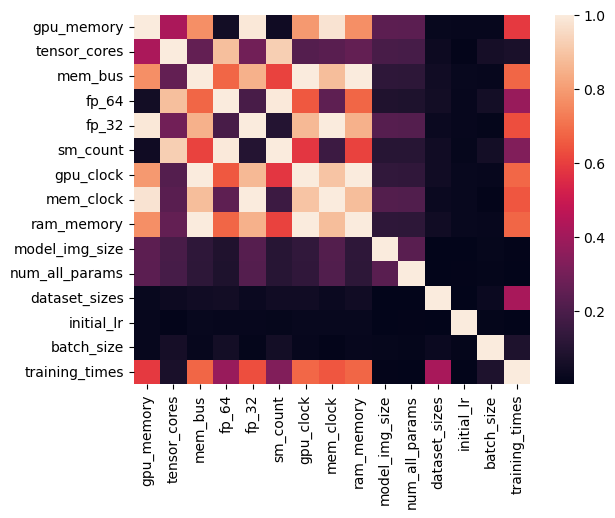

In [574]:
sns.heatmap(abs(data_num1.corr()))

In [575]:
target = 'training_times'

In [576]:
y = data_num[target]
X = data_num.drop([target, 
                   'epoch1_time', 
                   'epoch2_time',
                   'epoch3_time',
                   'epoch4_time',
                   'epoch5_time',
                   'epoch6_time',
                   'epoch7_time',
                   'epoch8_time',
                   'epoch9_time',
                   'epoch10_time'],
                  axis=1, errors='ignore')

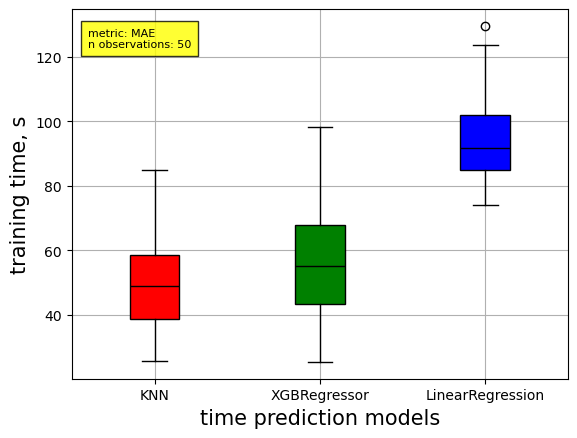

In [577]:
maes_knn = []
maes_xgb = []
maes_linear = []
for _ in range(50):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)
    
    knn = KNeighborsRegressor(n_neighbors=10)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    mae1 = mean_absolute_error(y_test, pred)
    maes_knn.append(mae1)

    xgb_r = xg.XGBRegressor(n_estimators = 10) 
    xgb_r.fit(X_train, y_train) 
    pred = xgb_r.predict(X_test)
    mae2 = mean_absolute_error(y_test, pred)
    maes_xgb.append(mae2)

    linear = LinearRegression()
    linear.fit(X_train, y_train)
    pred = linear.predict(X_test)
    mae3 = mean_absolute_error(y_test, pred)
    maes_linear.append(mae3)




maes = [maes_knn, maes_xgb, maes_linear]
labels = ['KNN', 'XGBRegressor', 'LinearRegression']
colors = ['red', 'green', 'blue']

fig, ax = plt.subplots()
ax.set_ylabel('training time, s', size=15)
ax.set_xlabel('time prediction models', size=15)

bplot = ax.boxplot(maes, patch_artist=True, labels=labels)
for median in bplot['medians']:
    median.set_color('black')
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

xcoords, ycoords = 0.15, 0.8
legen = 'metric: MAE \nn observations: 50'
plt.figtext(xcoords, ycoords, legen, bbox={'facecolor': 'yellow', 'alpha': 0.8, 'pad': 5}, fontsize=8)

plt.grid()
plt.show()

In [578]:
# X_train.columns

In [579]:
r2_score(y_test, pred)

0.515460111872015

In [580]:
mean_absolute_percentage_error(y_test, pred)

0.17965308157790436

In [581]:
mean_absolute_error(y_test, pred)

112.10581874618146

In [582]:
# data.columns

In [583]:
gpus_graph = data.loc[(data['model_name'] == 'ResNet') & 
(data['dataset_name'] == 'flowers-102') & 
(data['optimizer_name'] == 'Adadelta') &
(data['initial_lr'] == 0.001) &
(data['batch_size'] == 15)]

In [584]:
model_graph = data.loc[(data['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(data['dataset_name'] == 'flowers-102') & 
(data['optimizer_name'] == 'Adadelta') &
(data['initial_lr'] == 0.001) &
(data['batch_size'] == 15)]

In [585]:
dataset_graph = data.loc[(data['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(data['model_name'] == 'ResNet') & 
(data['optimizer_name'] == 'Adadelta') &
(data['initial_lr'] == 0.001) &
(data['batch_size'] == 15)]

In [586]:
optimizer_graph = data.loc[(data['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(data['model_name'] == 'ResNet') & 
(data['dataset_name'] == 'flowers-102') &
(data['initial_lr'] == 0.001) &
(data['batch_size'] == 15)]

In [587]:
lr_graph = data.loc[(data['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(data['model_name'] == 'ResNet') & 
(data['dataset_name'] == 'flowers-102') &
(data['optimizer_name'] == 'Adadelta') &
(data['batch_size'] == 15)]

In [588]:
batch_graph = data.loc[(data['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(data['model_name'] == 'ResNet') & 
(data['dataset_name'] == 'flowers-102') &
(data['optimizer_name'] == 'Adadelta') &
(data['initial_lr'] == 0.001)]

In [589]:
epochs_graph1 = data.loc[(data['model_name'] == 'VisionTransformer') &
(data['dataset_name'] == 'fgvc-aircraft-2013b') &
(data['optimizer_name'] == 'Adadelta') &
(data['initial_lr'] == 0.0001) & 
(data['batch_size'] == 10)]

In [590]:
epochs_graph2 = data.loc[(data['model_name'] == 'SqueezeNet') &
(data['dataset_name'] == 'fgvc-aircraft-2013b') &
(data['optimizer_name'] == 'Adadelta') &
(data['initial_lr'] == 0.001) & 
(data['batch_size'] == 15)]

In [591]:
epochs_graph3 = data.loc[(data['model_name'] == 'ResNet') &
(data['dataset_name'] == 'flowers-102') &
(data['optimizer_name'] == 'Adamax') &
(data['initial_lr'] == 0.01) & 
(data['batch_size'] == 20) &
(data['gpu_name'] == 'NVIDIA GeForce GTX 1650 Ti')]

In [592]:
def show_graph(df, x):
    x_vals = df[x].to_list()
    x_vals = list(map(lambda x: str(x), x_vals))
    y_vals = df['training_times'].to_list()

    df1 = df.loc[:, ['gpu_name', 'model_name', 'dataset_name', 'optimizer_name', 'initial_lr', 'batch_size']]
    df1.drop(x, axis=1, inplace=True)
    legen = '\n'.join(str(*df1.head(1).to_dict('records')).strip('{}').split(','))
    
    plt.figure(figsize=(6, 6))
    plt.bar(x_vals, y_vals, color=['blue', 'green', 'red'], width=0.5)
    plt.xlabel(x, size=15)
    plt.ylabel('training_time, s', size=15)
    plt.title(f'Сравнение {x}')
    plt.xticks(rotation=10)
    ax = plt.gca()
    ax.set_ylim([0, max(y_vals) * 1.3])
    xcoords, ycoords = 0.15, 0.75
    plt.figtext(xcoords, ycoords, legen, bbox={'facecolor': 'yellow', 'alpha': 0.8, 'pad': 5}, fontsize=8)
    plt.grid()
    plt.show()

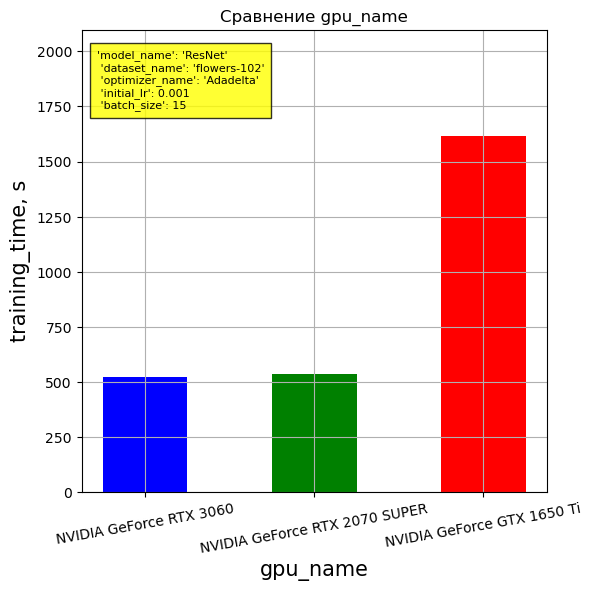

In [593]:
show_graph(gpus_graph, 'gpu_name')

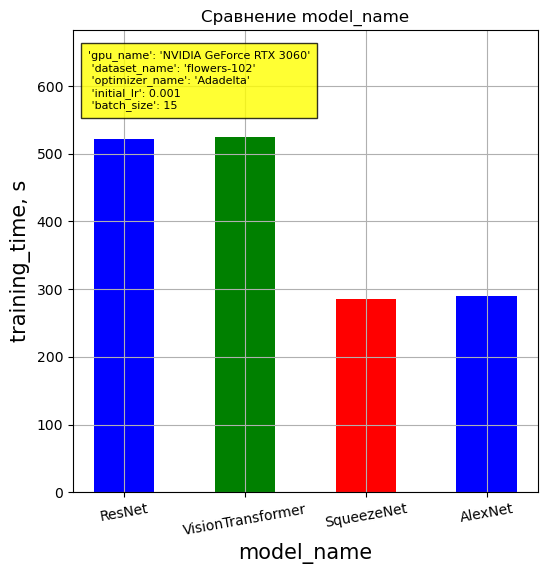

In [594]:
show_graph(model_graph, 'model_name')

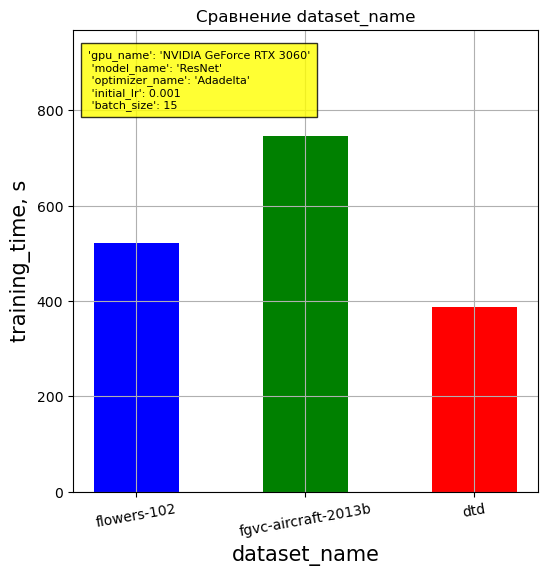

In [595]:
show_graph(dataset_graph, 'dataset_name')

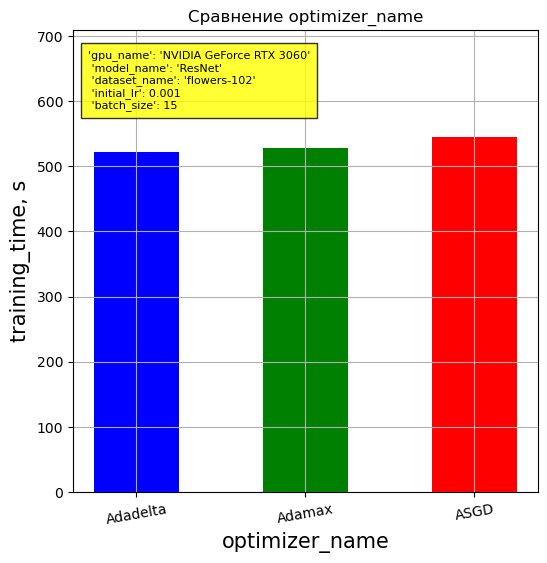

In [596]:
show_graph(optimizer_graph, 'optimizer_name')

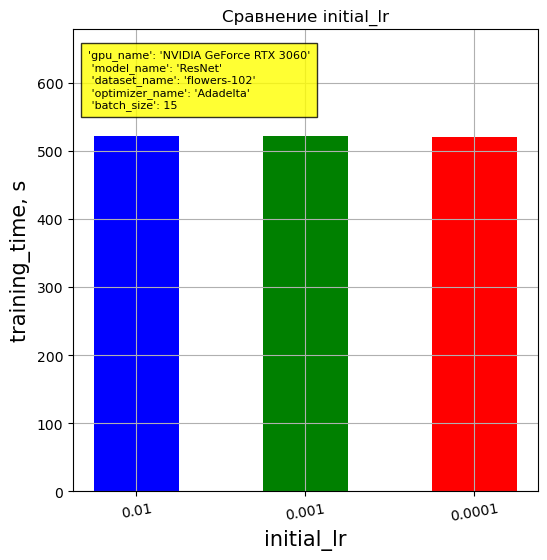

In [597]:
show_graph(lr_graph, 'initial_lr')

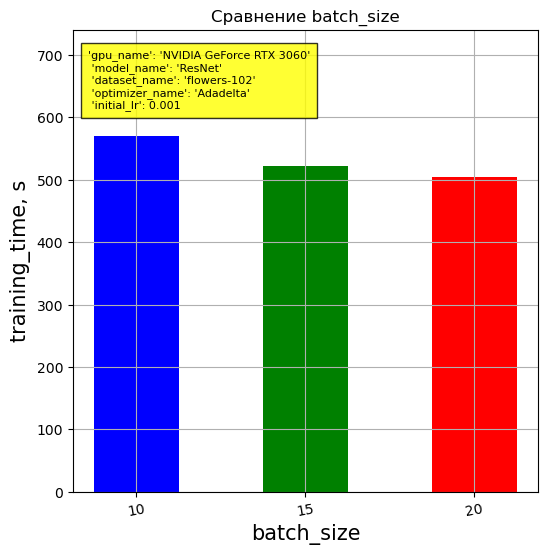

In [598]:
show_graph(batch_graph, 'batch_size')

In [599]:
epochs_graph1

,cpu_name,gpu_name,gpu_memory,ram_memory,model_name,model_img_size,num_all_params,dataset_name,dataset_sizes,optimizer_name,...,epoch1_time,epoch2_time,epoch3_time,epoch4_time,epoch5_time,epoch6_time,epoch7_time,epoch8_time,epoch9_time,epoch10_time
110,AMD Ryzen 7 5700X 8-Core Processor,NVIDIA GeForce RTX 3060,12.0,32,VisionTransformer,224,88224232,fgvc-aircraft-2013b,10000,Adadelta,...,81.83983,81.746349,81.863414,82.159565,81.810455,81.967932,81.78807,81.98695,81.82191,82.104725


In [628]:
def show_epochs(df):
    x_vals = list(range(1, 11))
    y_vals = df.loc[:, ['epoch1_time', 
                        'epoch2_time', 
                        'epoch3_time', 
                        'epoch4_time', 
                        'epoch5_time',
                        'epoch6_time', 
                        'epoch7_time', 
                        'epoch8_time', 
                        'epoch9_time', 
                        'epoch10_time']].values.flatten()

    df1 = df.loc[:, ['gpu_name', 'model_name', 'dataset_name', 'optimizer_name', 'initial_lr', 'batch_size']]
    legen = '\n'.join(str(*df1.head(1).to_dict('records')).strip('{}').split(','))
    
    plt.figure(figsize=(8, 6))
    plt.bar(x_vals, y_vals, width=0.5)
    plt.xlabel('epochs', size=15)
    plt.ylabel('epoch_times, s', size=15)
    plt.title(f'Сравнение времени эпох')
    plt.xticks(range(1, 11), rotation=10)
    ax = plt.gca()
    ax.set_ylim([0, max(y_vals) * 1.3])
    xcoords, ycoords = 0.15, 0.74
    plt.figtext(xcoords, ycoords, legen, bbox={'facecolor': 'yellow', 'alpha': 0.8, 'pad': 5}, fontsize=8)
    plt.grid()
    plt.show()

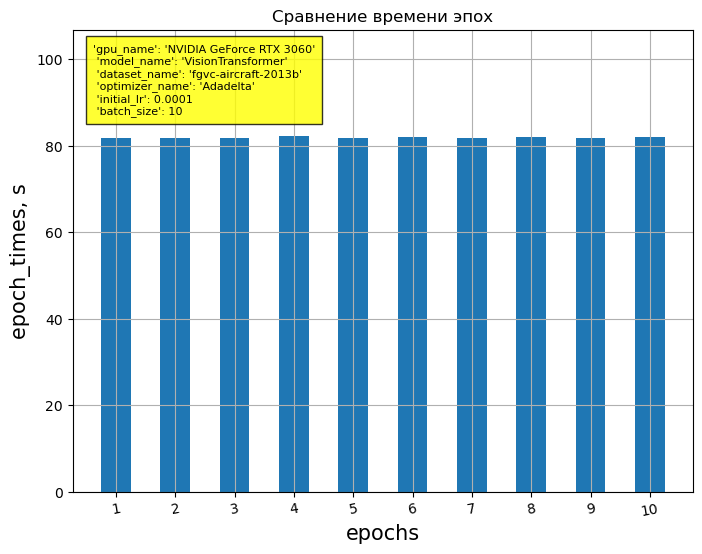

In [629]:
show_epochs(epochs_graph1)

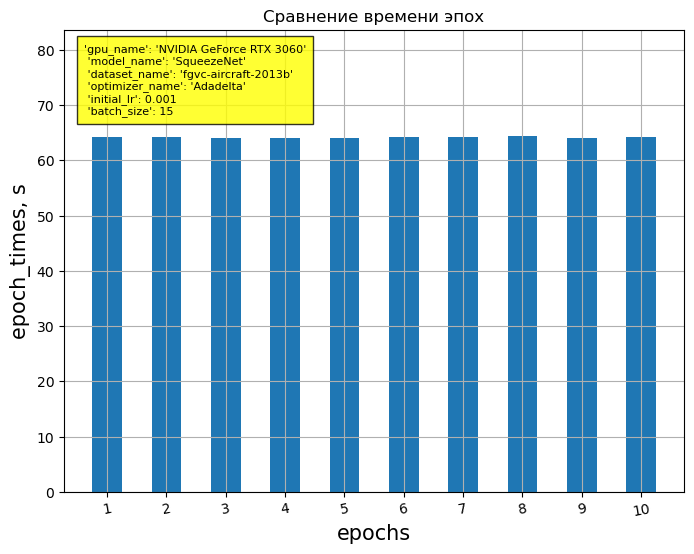

In [630]:
show_epochs(epochs_graph2)

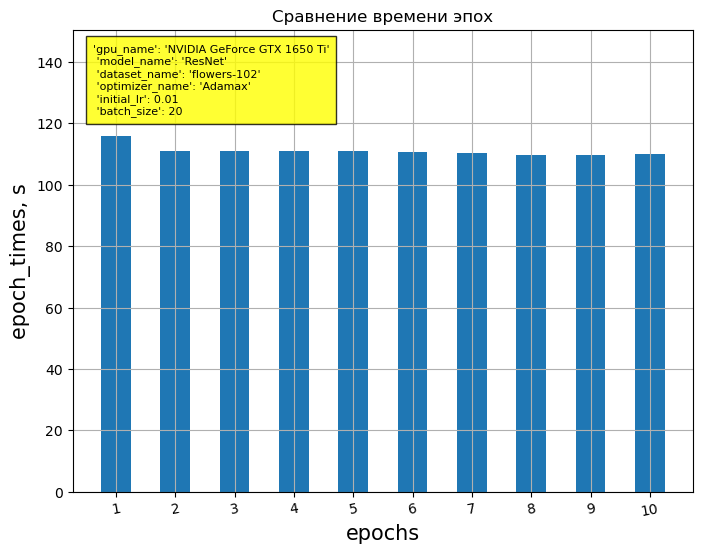

In [631]:
show_epochs(epochs_graph3)